Exploratory Data Analysis (EDA)

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = 12

pd.set_option("display.max_columns", None)

In [2]:
PROJECT_ROOT = Path("..")

EDA_PLOT_DIR = PROJECT_ROOT / "outputs" / "plots"

EDA_PLOT_DIR.mkdir(parents=True, exist_ok=True)


def save_plot(filename):
    plt.tight_layout()
    plt.savefig(
        EDA_PLOT_DIR / filename,
        dpi=300,
        bbox_inches="tight"
    )
    print(f"Saved: {filename}")

Load processed one

In [3]:
DATA_PATH = "../datasets/processed/processed_train.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,image_path,Sampling_Date,State,Species,NDVI,Height_cm,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g
0,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,0.0000,31.9984,16.2751,48.2735,16.2750
1,train/ID1012260530.jpg,2015/4/1,NSW,Lucerne,0.55,16.0000,0.0000,0.0000,7.6000,7.6000,7.6000
2,train/ID1025234388.jpg,2015/9/1,WA,SubcloverDalkeith,0.38,1.0000,6.0500,0.0000,0.0000,6.0500,6.0500
3,train/ID1028611175.jpg,2015/5/18,Tas,Ryegrass,0.66,5.0000,0.0000,30.9703,24.2376,55.2079,24.2376
4,train/ID1035947949.jpg,2015/9/11,Tas,Ryegrass,0.54,3.5000,0.4343,23.2239,10.5261,34.1844,10.9605


Dataset Overview

In [4]:
print("="*60)
print("DATASET SHAPE")
print("="*60)

print(df.shape)

print("\n")

print("="*60)
print("DATA TYPES")
print("="*60)

print(df.dtypes)

print("\n")

print("="*60)
print("MISSING VALUES")
print("="*60)

print(df.isnull().sum())

DATASET SHAPE
(357, 11)


DATA TYPES
image_path        object
Sampling_Date     object
State             object
Species           object
NDVI             float64
Height_cm        float64
Dry_Clover_g     float64
Dry_Dead_g       float64
Dry_Green_g      float64
Dry_Total_g      float64
GDM_g            float64
dtype: object


MISSING VALUES
image_path       0
Sampling_Date    0
State            0
Species          0
NDVI             0
Height_cm        0
Dry_Clover_g     0
Dry_Dead_g       0
Dry_Green_g      0
Dry_Total_g      0
GDM_g            0
dtype: int64


Summary stats

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
NDVI,357.0,0.657423,0.152142,0.16,0.5600,0.6900,0.7700,0.9100
Height_cm,357.0,7.595985,10.285262,1.00,3.0000,4.0000,7.0000,70.0000
Dry_Clover_g,357.0,6.649692,12.117761,0.00,0.0000,1.4235,7.2429,71.7865
Dry_Dead_g,357.0,12.044548,12.402007,0.00,3.2000,7.9809,17.6378,83.8407
Dry_Green_g,357.0,26.624722,25.401232,0.00,8.8000,20.8000,35.0834,157.9836
Dry_Total_g,357.0,45.318097,27.984015,1.04,25.2715,40.3000,57.8800,185.7000
GDM_g,357.0,33.274414,24.935822,1.04,16.0261,27.1082,43.6757,157.9836


target colms

In [6]:
target_columns = [
    "Dry_Clover_g",
    "Dry_Dead_g",
    "Dry_Green_g",
    "Dry_Total_g",
    "GDM_g"
]

target_columns

['Dry_Clover_g', 'Dry_Dead_g', 'Dry_Green_g', 'Dry_Total_g', 'GDM_g']

Biomass Distribution

Saved: biomass_distribution.png


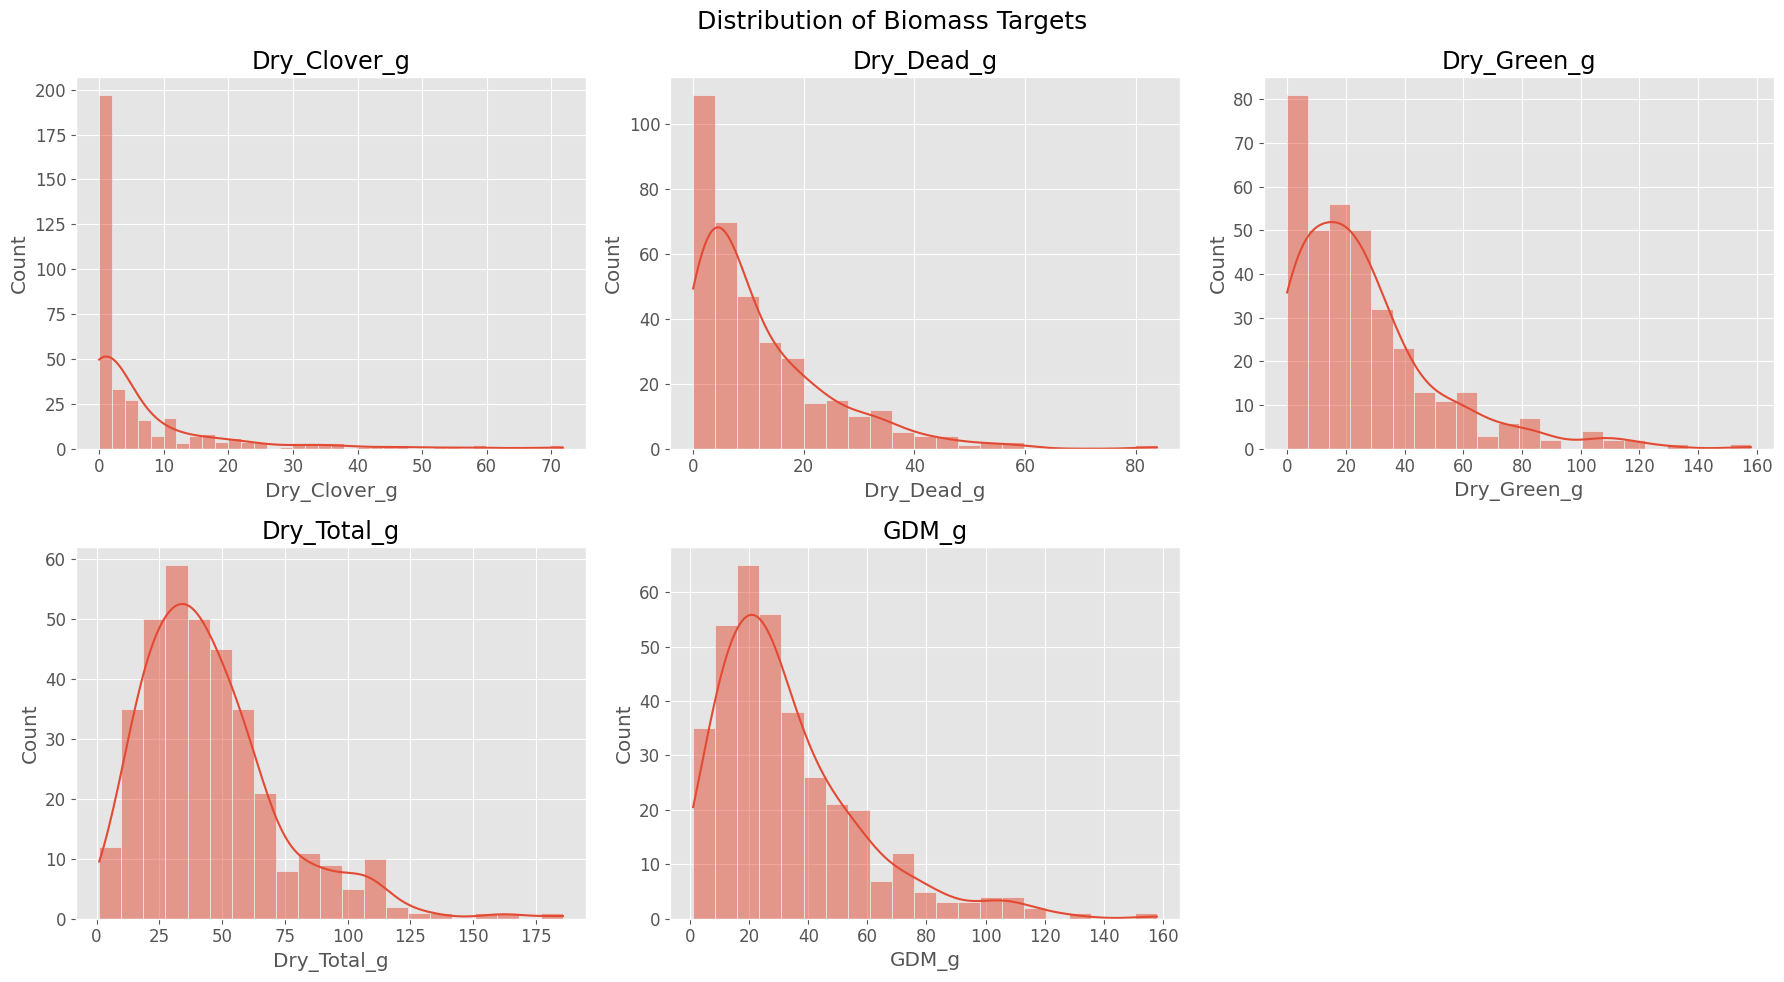

In [7]:
fig, axes = plt.subplots(2,3, figsize=(18,10))

axes = axes.flatten()

for i, col in enumerate(target_columns):

    sns.histplot(
        data=df,
        x=col,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(col)

axes[-1].axis("off")

plt.suptitle("Distribution of Biomass Targets", fontsize=18)

save_plot("biomass_distribution.png")

plt.show()

In [9]:
print(df.columns.tolist())

['image_path', 'Sampling_Date', 'State', 'Species', 'NDVI', 'Height_cm', 'Dry_Clover_g', 'Dry_Dead_g', 'Dry_Green_g', 'Dry_Total_g', 'GDM_g']


Correlation

Saved: correlation_heatmap.png


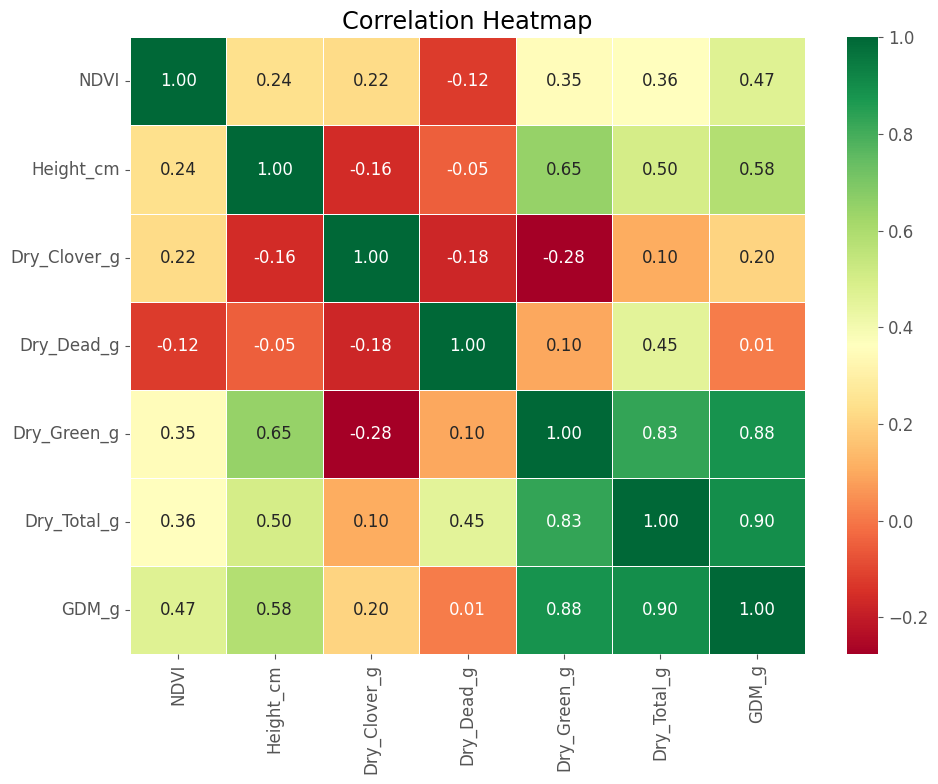

In [10]:
corr_columns = [
    "NDVI",
    "Height_cm",
    "Dry_Clover_g",
    "Dry_Dead_g",
    "Dry_Green_g",
    "Dry_Total_g",
    "GDM_g"
]

corr = df[corr_columns].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdYlGn",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

save_plot("correlation_heatmap.png")

plt.show()

Species distribution

Saved: species_distribution.png


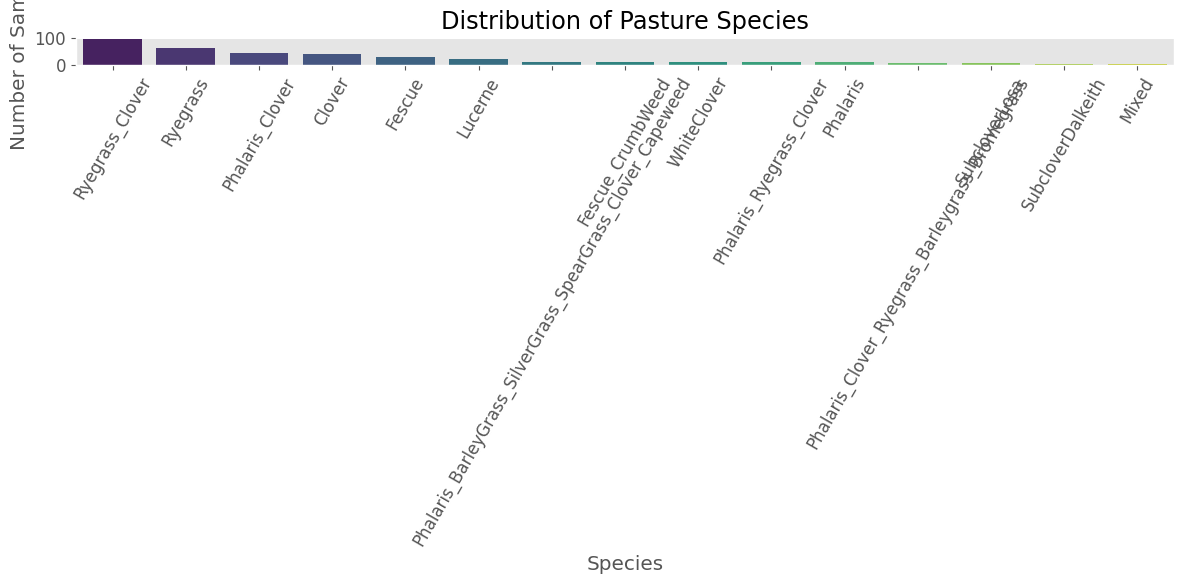

In [11]:
plt.figure(figsize=(12,6))

species_counts = (
    df["Species"]
    .value_counts()
    .sort_values(ascending=False)
)

sns.barplot(
    x=species_counts.index,
    y=species_counts.values,
    palette="viridis"
)

plt.title("Distribution of Pasture Species")
plt.xlabel("Species")
plt.ylabel("Number of Samples")
plt.xticks(rotation=60)

save_plot("species_distribution.png")

plt.show()

State Distribution

Saved: state_distribution.png


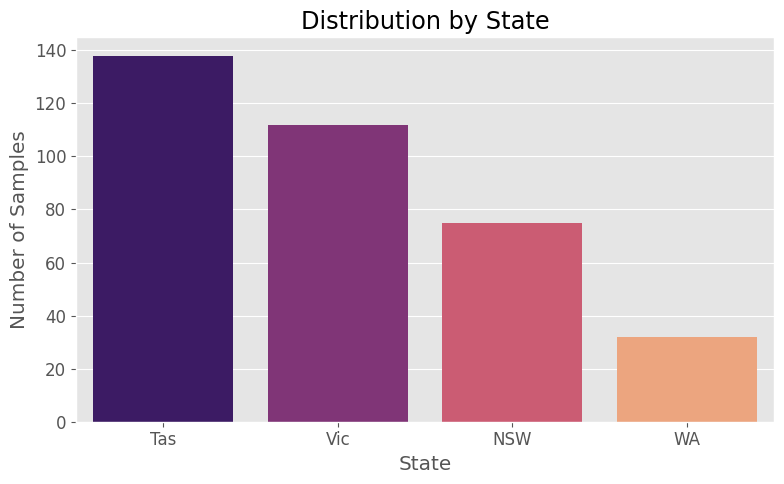

In [12]:
plt.figure(figsize=(8,5))

state_counts = df["State"].value_counts()

sns.barplot(
    x=state_counts.index,
    y=state_counts.values,
    palette="magma"
)

plt.title("Distribution by State")
plt.xlabel("State")
plt.ylabel("Number of Samples")

save_plot("state_distribution.png")

plt.show()

AVG biomass (species)

Saved: average_biomass_species.png


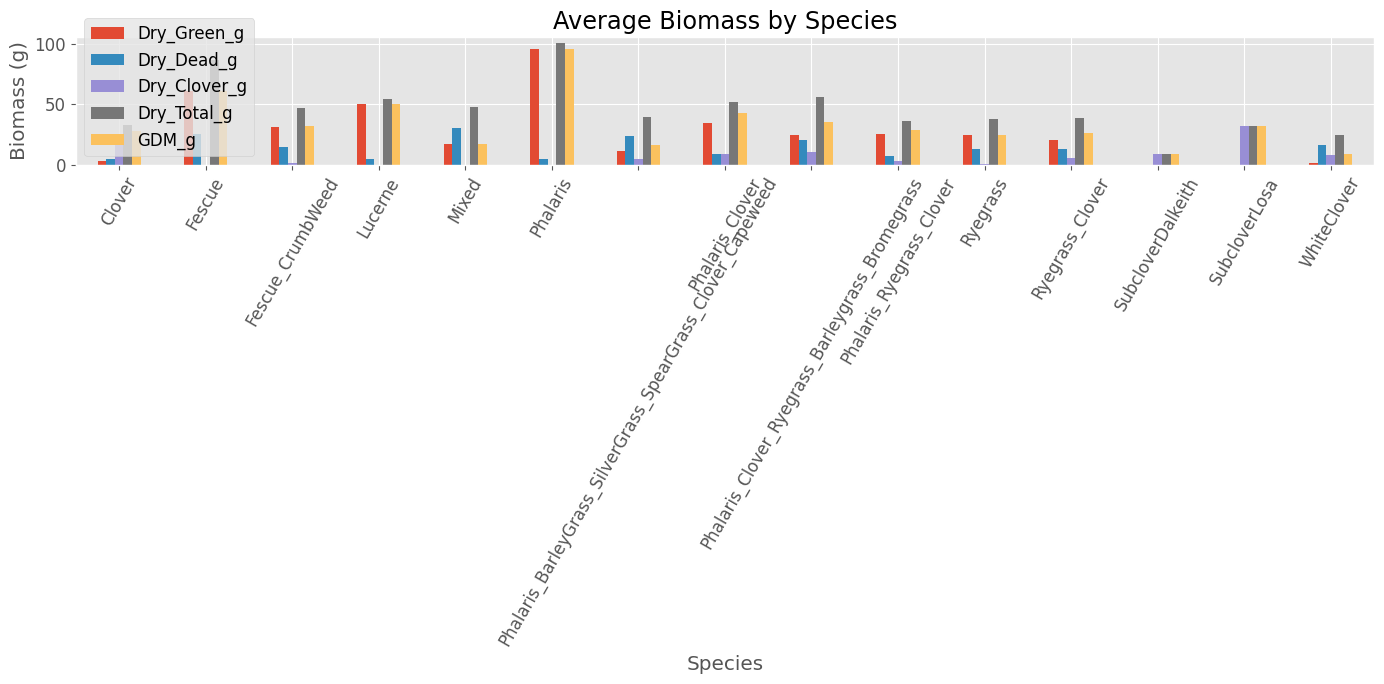

In [13]:
biomass_cols = [
    "Dry_Green_g",
    "Dry_Dead_g",
    "Dry_Clover_g",
    "Dry_Total_g",
    "GDM_g"
]

species_mean = (
    df.groupby("Species")[biomass_cols]
      .mean()
)

species_mean.plot(
    kind="bar",
    figsize=(14,7)
)

plt.title("Average Biomass by Species")
plt.ylabel("Biomass (g)")
plt.xticks(rotation=60)

save_plot("average_biomass_species.png")

plt.show()

Avg Biomass (state)

Saved: average_biomass_state.png


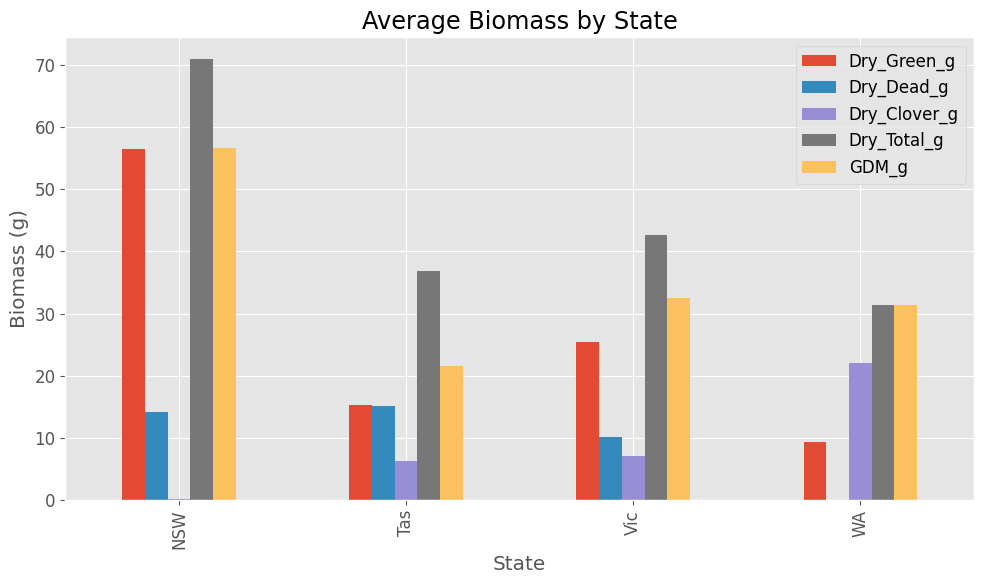

In [14]:
state_mean = (
    df.groupby("State")[biomass_cols]
      .mean()
)

state_mean.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Biomass by State")
plt.ylabel("Biomass (g)")

save_plot("average_biomass_state.png")

plt.show()

NDVI vs Total Biomass

Saved: ndvi_vs_total.png


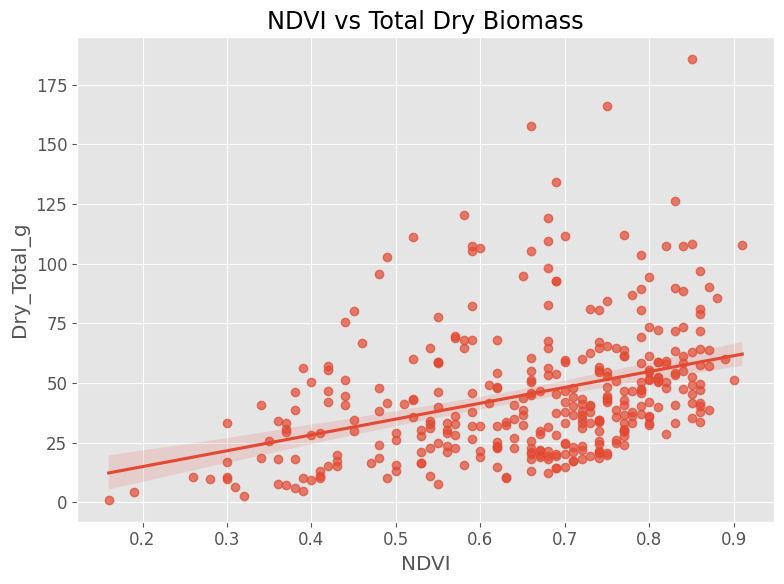

In [15]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="NDVI",
    y="Dry_Total_g",
    scatter_kws={"alpha":0.7}
)

plt.title("NDVI vs Total Dry Biomass")

save_plot("ndvi_vs_total.png")

plt.show()

Height vs Total Biomass

Saved: height_vs_total.png


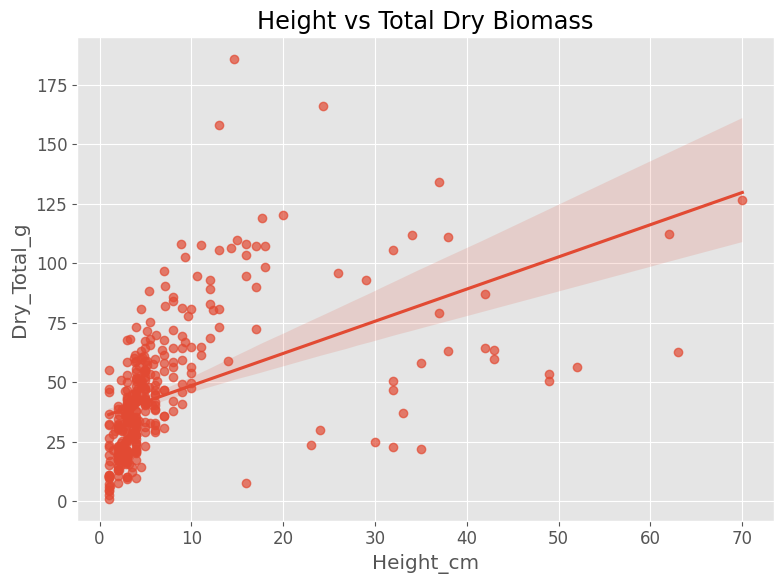

In [16]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="Height_cm",
    y="Dry_Total_g",
    scatter_kws={"alpha":0.7}
)

plt.title("Height vs Total Dry Biomass")

save_plot("height_vs_total.png")

plt.show()

Outliers

Saved: outliers.png


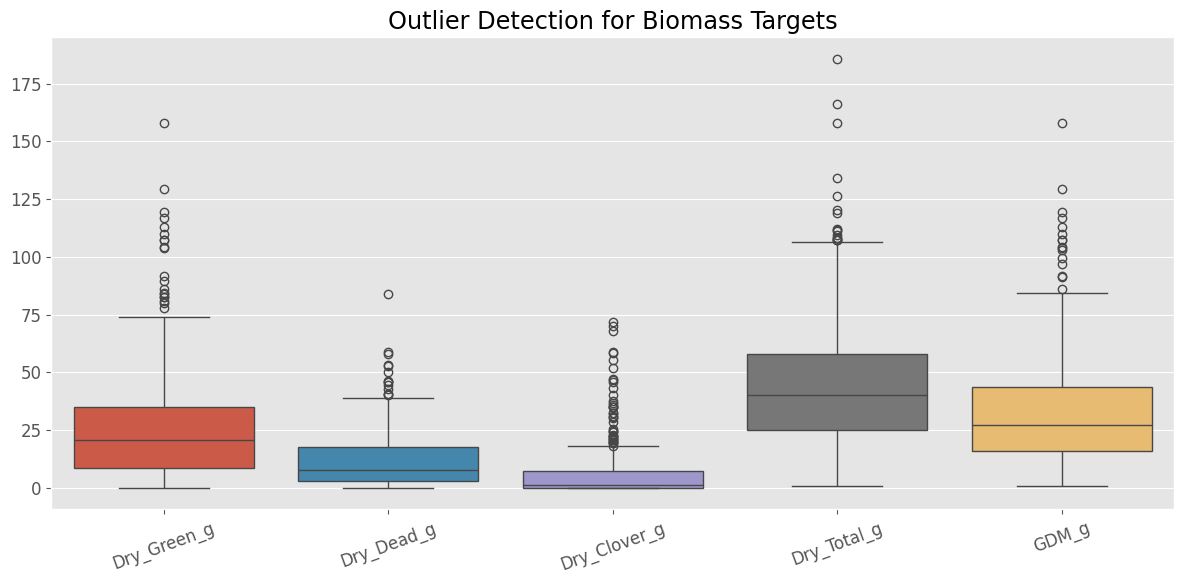

In [17]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df[biomass_cols])

plt.title("Outlier Detection for Biomass Targets")
plt.xticks(rotation=20)

save_plot("outliers.png")

plt.show()

# Computer Vision EDA

This section explores the RGB pasture images to understand their visual characteristics before preprocessing and model development.

In [18]:
from PIL import Image
import random
import os

In [19]:
PROJECT_ROOT = Path("..")

IMAGE_DIR = PROJECT_ROOT / "datasets" / "raw"

IMAGE_DIR

WindowsPath('../datasets/raw')

Random Images

Saved: sample_images.png


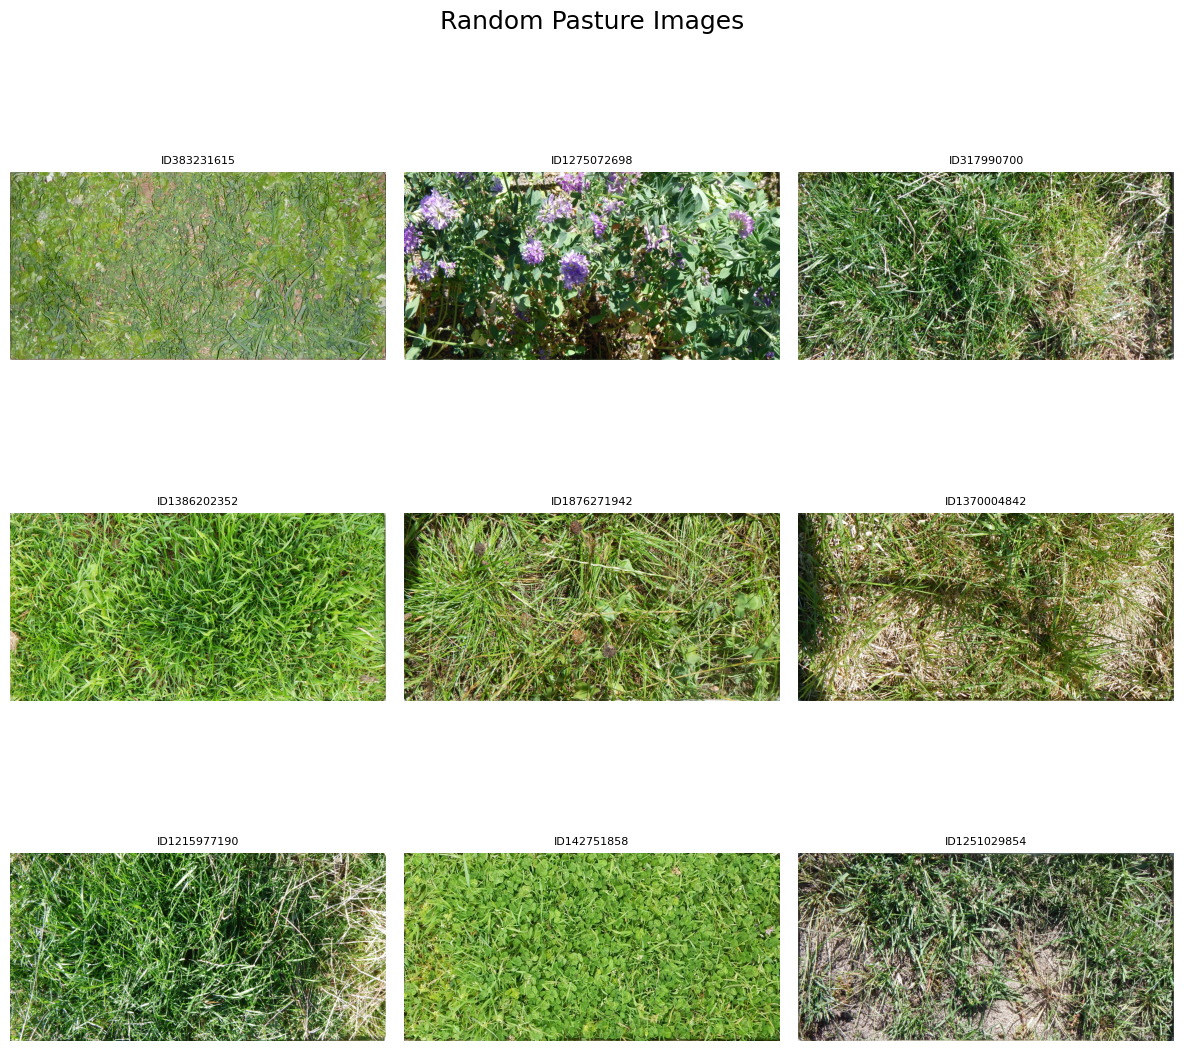

In [20]:
sample_images = random.sample(df["image_path"].tolist(), 9)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, img_path in zip(axes.flatten(), sample_images):

    image = Image.open(IMAGE_DIR / img_path)

    ax.imshow(image)
    ax.set_title(Path(img_path).stem, fontsize=8)
    ax.axis("off")

plt.suptitle("Random Pasture Images", fontsize=18)

save_plot("sample_images.png")

plt.show()

Checking the resolution of the images

In [21]:
widths = []
heights = []

for img_path in df["image_path"]:

    image = Image.open(IMAGE_DIR / img_path)

    w, h = image.size

    widths.append(w)
    heights.append(h)

resolution_df = pd.DataFrame({
    "Width": widths,
    "Height": heights
})

resolution_df.head()

,Width,Height
0,2000,1000
1,2000,1000
2,2000,1000
3,2000,1000
4,2000,1000


In [22]:
resolution_df.describe()

,Width,Height
count,357.0,357.0
mean,2000.0,1000.0
std,0.0,0.0
min,2000.0,1000.0
25%,2000.0,1000.0
50%,2000.0,1000.0
75%,2000.0,1000.0
max,2000.0,1000.0


Plotting

Saved: image_resolution_distribution.png


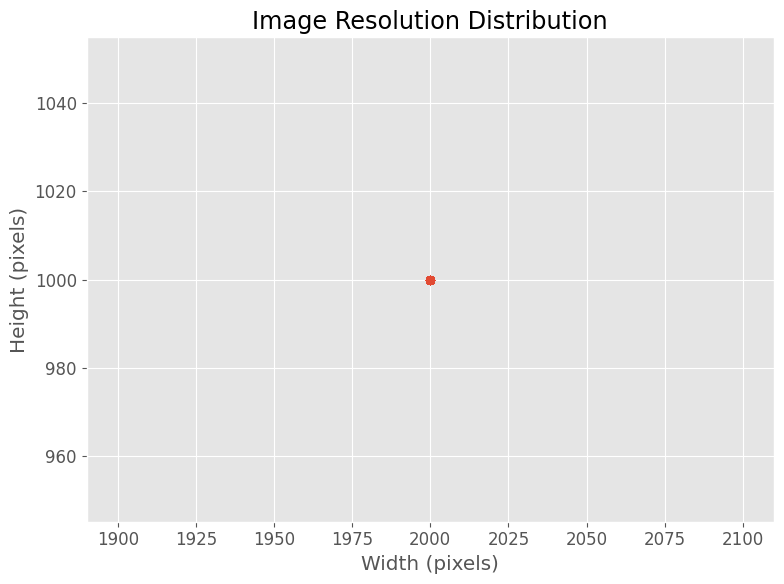

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(
    widths,
    heights,
    alpha=0.6
)

plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")
plt.title("Image Resolution Distribution")

save_plot("image_resolution_distribution.png")

plt.show()

Image aspect ratio

Saved: aspect_ratio_distribution.png


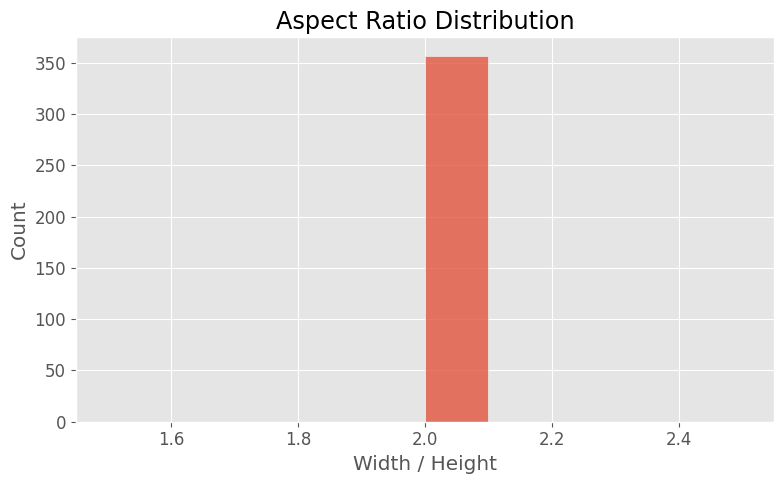

Unique Aspect Ratios: [2.]


In [24]:
aspect_ratio = resolution_df["Width"] / resolution_df["Height"]

plt.figure(figsize=(8,5))

sns.histplot(aspect_ratio, bins=10)

plt.title("Aspect Ratio Distribution")
plt.xlabel("Width / Height")

save_plot("aspect_ratio_distribution.png")

plt.show()

print("Unique Aspect Ratios:", aspect_ratio.unique())